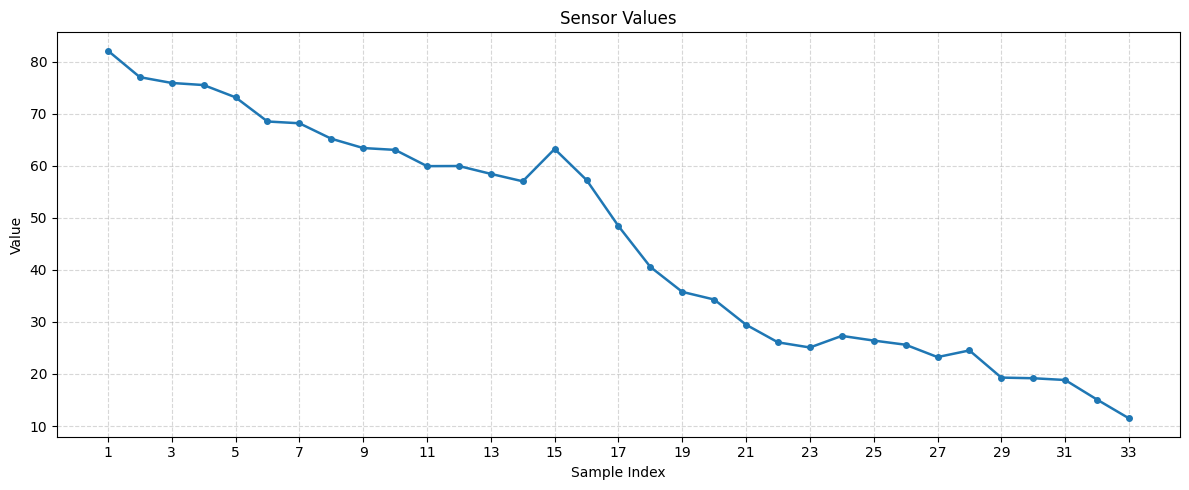

In [5]:
import matplotlib.pyplot as plt

values = [
    82.0718,
    76.9931,
    75.8793,
    75.4759,
    73.1170,
    68.4803,
    68.1380,
    65.1699,
    63.3804,
    63.0284,
    59.9043,
    59.9296,
    58.4216,
    56.9954,
    63.1981,
    57.2445,
    48.3960,
    40.5526,
    35.7585,
    34.2899,
    29.4515,
    26.0669,
    25.0799,
    27.3085,
    26.4092,
    25.6090,
    23.2370,
    24.5159,
    19.2986,
    19.1738,
    18.8365,
    15.0758,
    11.4737,
]

x = list(range(1, len(values) + 1))

plt.figure(figsize=(12, 5))
plt.plot(x, values, marker="o", linewidth=1.8, markersize=4)
plt.title("Sensor Values")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(range(1, len(values) + 1, 2))
plt.tight_layout()
plt.show()

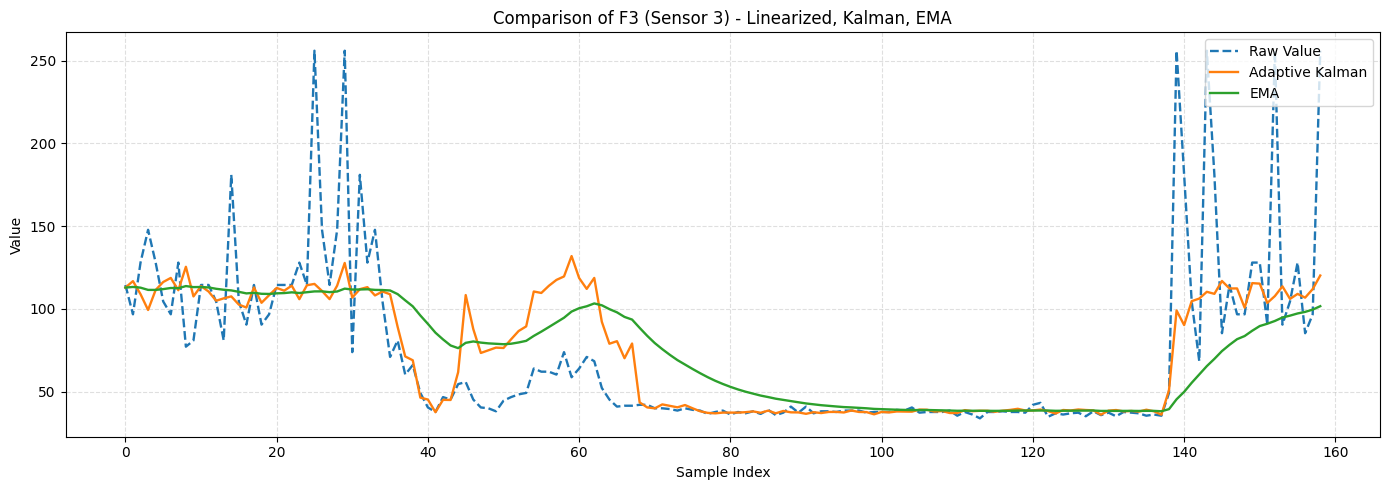

In [31]:
# Compare only F3 (sensor 3) for each method, single plot, English labels
import numpy as np
import matplotlib.pyplot as plt

# --- Linearize logic from flame.c (_get_linearize_sensor_data) ---
def linearize_sensor(raw):
    v = np.clip(raw, 1, None)
    v = 0xffff / v - 1
    v = np.sqrt(v)
    return v

# F3 (sensor 3) values
f3_raw = raw_arr[:, 3]
f3_linearized = linearize_sensor(f3_raw)
f3_kalman = f_arr[:, 3]

ema_alpha = 0.1
f3_ema = np.zeros_like(f3_kalman)
f3_ema[0] = f3_kalman[0]
for i in range(1, len(f3_kalman)):
    f3_ema[i] = ema_alpha * f3_kalman[i] + (1 - ema_alpha) * f3_ema[i-1]

window = 10
f3_ma = np.zeros_like(f3_kalman)
for i in range(len(f3_kalman)):
    f3_ma[i] = np.mean(f3_kalman[max(0, i-window+1):i+1])

plt.figure(figsize=(14, 5))
plt.plot(f3_linearized, label='Raw Value', color='tab:blue', linewidth=1.7, linestyle='dashed')
plt.plot(f3_kalman, label='Adaptive Kalman', color='tab:orange', linewidth=1.7)
plt.plot(f3_ema, label='EMA', color='tab:green', linewidth=1.7)
# Removed red line (Moving Avg) as requested
plt.title('Comparison of F3 (Sensor 3) - Linearized, Kalman, EMA')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Parsed 159 samples
RAW shape=(159, 4), F shape=(159, 4), V shape=(159, 2)


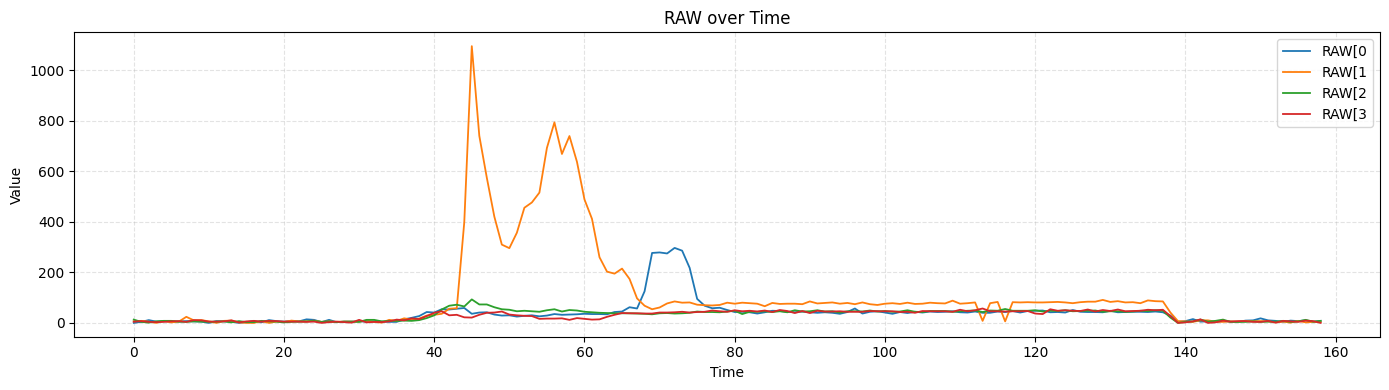

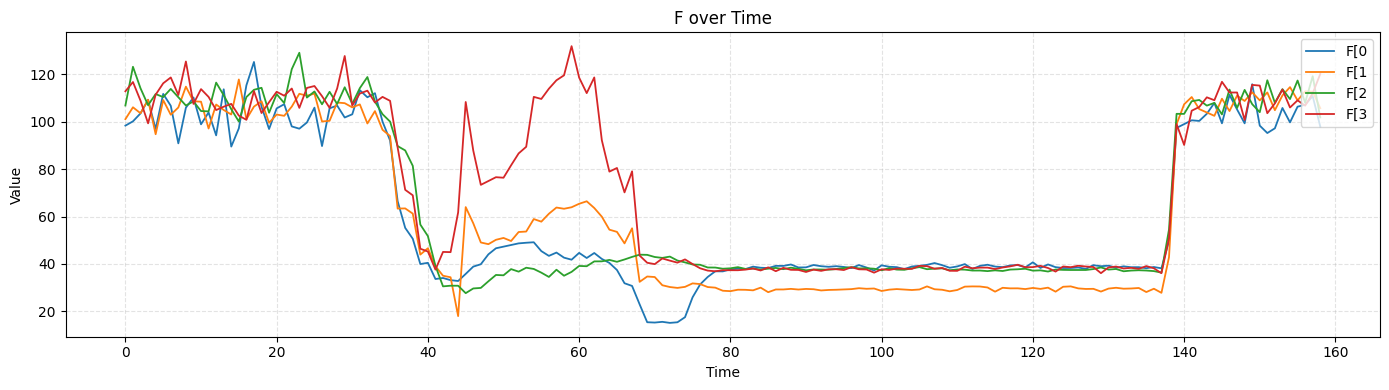

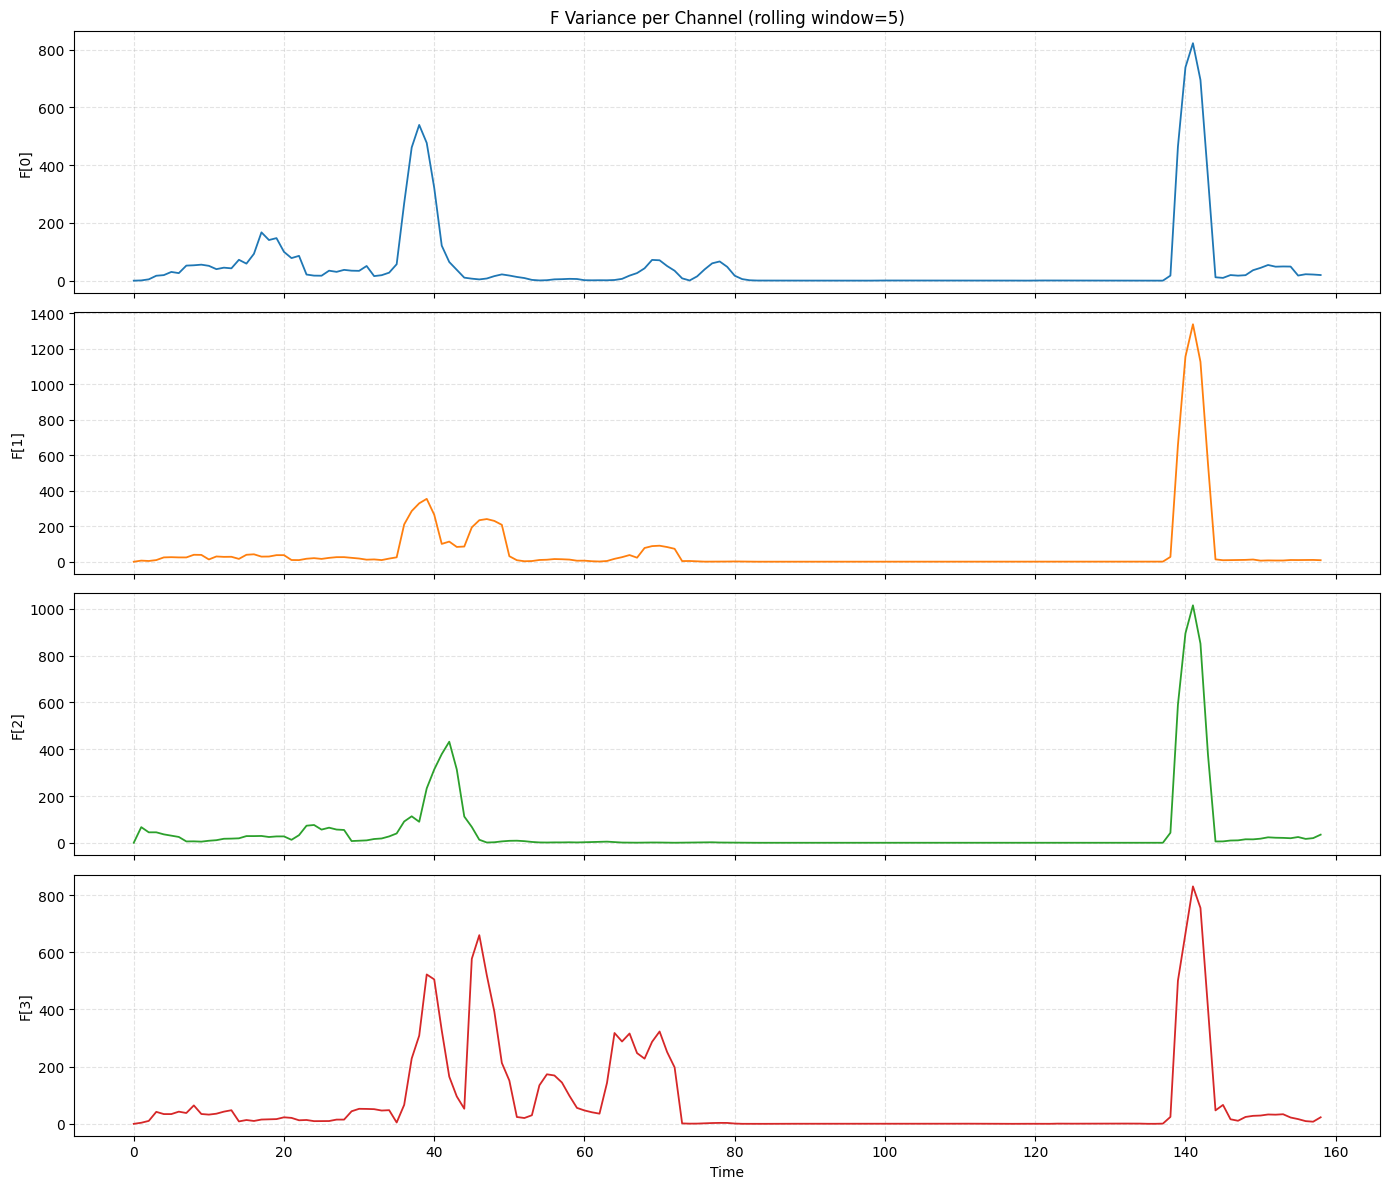

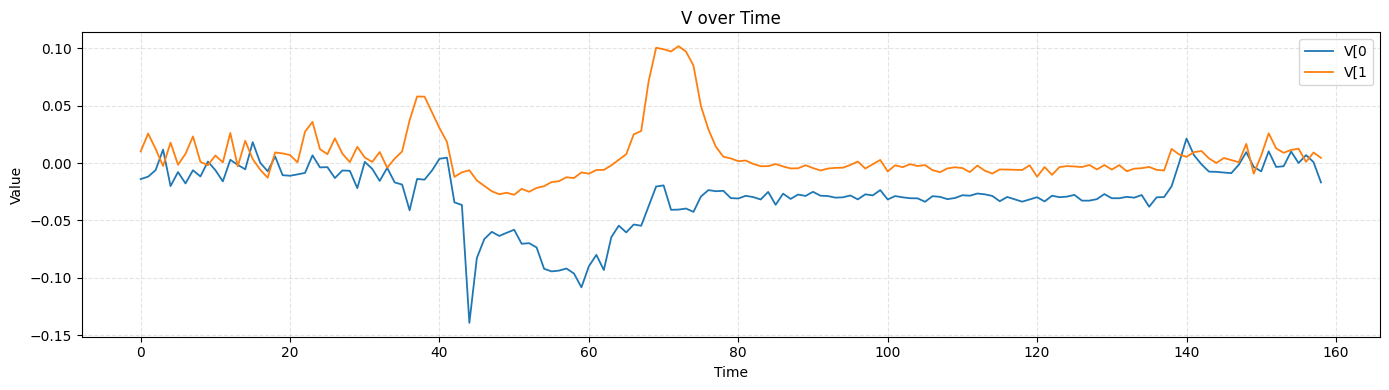

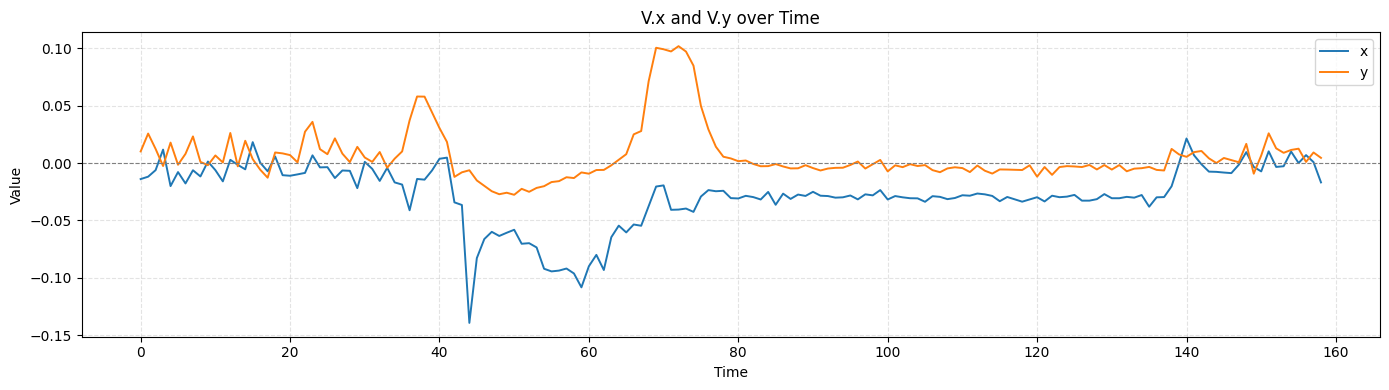

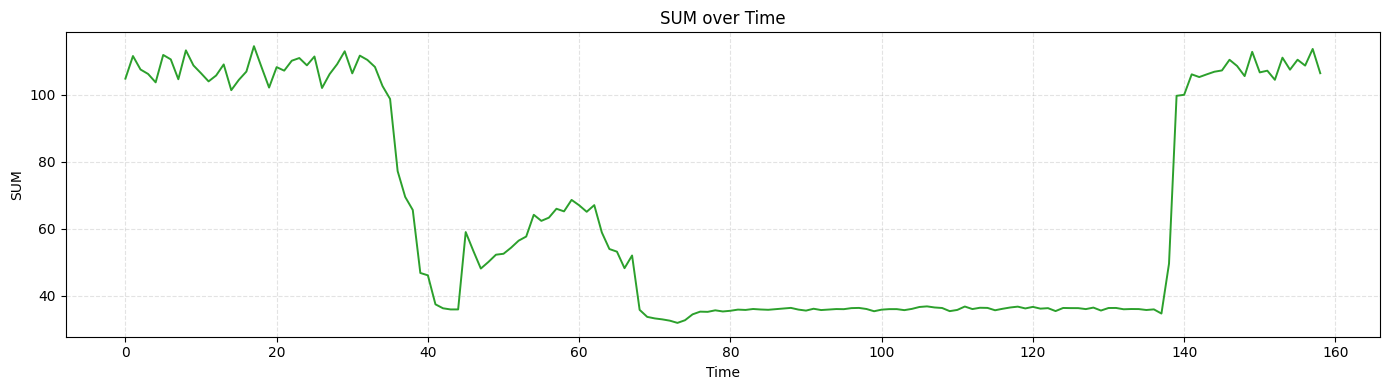

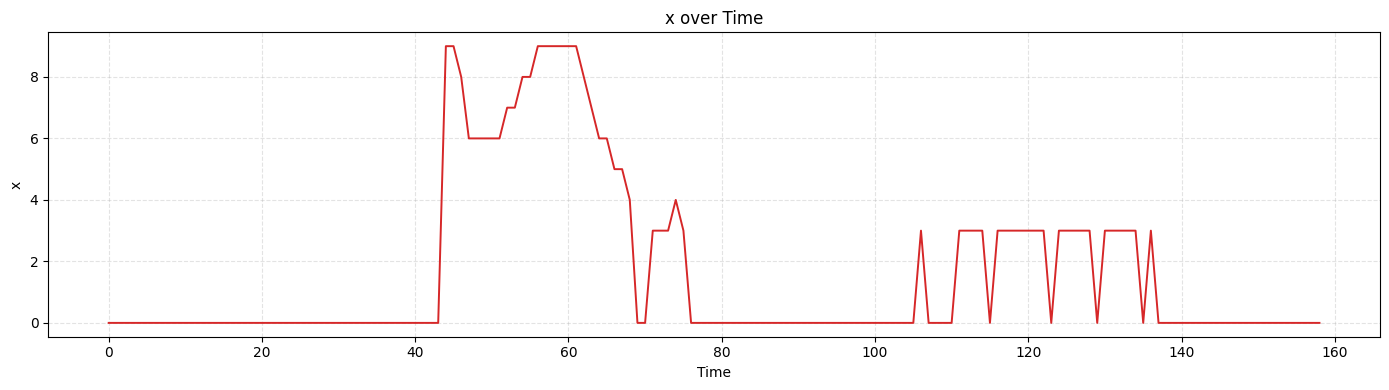

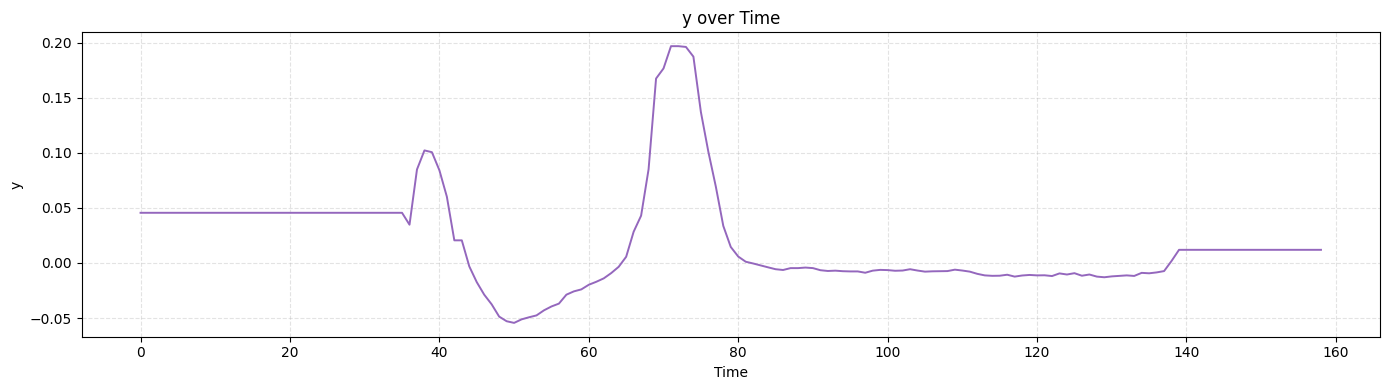

In [22]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# If one sample corresponds to fixed time (seconds), set dt (e.g., 0.01).
# Keep 1.0 to use sample index as time step.
dt = 1.0

data_path = Path("data.txt")
if not data_path.exists():
    raise FileNotFoundError(f"Cannot find {data_path.resolve()}")

# UART 출력이 SUM= 뒤에서 줄바꿈되므로, RAW로 시작하지 않는 줄을 이전 줄에 붙임
raw_text = data_path.read_text(encoding="utf-8")
joined = re.sub(r"\r?\n(?!RAW)", " ", raw_text)

line_pattern = re.compile(
    r"RAW=\[(?P<raw>[^\]]+)\]\s*"
    r"F=\[(?P<f>[^\]]+)\]\s*"
    r"V=\[(?P<v>[^\]]+)\]\s*"
    r"SUM=\s*(?P<sum>[-+]?\d*\.?\d+)\s*"
    r"(?:ANG=\s*(?P<ang>[-+]?\d*\.?\d+))?\s*"
    r"(?:x=\s*(?P<x>[-+]?\d*\.?\d+))?\s*"
    r"(?:y=\s*(?P<y>[-+]?\d*\.?\d+))?"
)

def parse_vector(text):
    return [float(x) for x in text.split()]

raw_list, f_list, v_list, sum_list, x_list, y_list = [], [], [], [], [], []
for line in joined.splitlines():
    line = line.strip()
    if not line:
        continue

    m = line_pattern.match(line)
    if not m:
        continue

    raw_vals = parse_vector(m.group("raw"))
    f_vals = parse_vector(m.group("f"))
    v_vals = parse_vector(m.group("v"))

    raw_list.append(raw_vals)
    f_list.append(f_vals)
    v_list.append(v_vals)
    sum_list.append(float(m.group("sum")))
    x_list.append(float(m.group("x")) if m.group("x") else 0.0)
    y_list.append(float(m.group("y")) if m.group("y") else 0.0)

if not raw_list:
    raise ValueError("No valid lines were parsed from data.txt")

raw_arr = np.array(raw_list)
f_arr = np.array(f_list)
v_arr = np.array(v_list)
sum_arr = np.array(sum_list)
x_arr = np.array(x_list)
y_arr = np.array(y_list)

n = len(sum_arr)
t = np.arange(n) * dt

print(f"Parsed {n} samples")
print(f"RAW shape={raw_arr.shape}, F shape={f_arr.shape}, V shape={v_arr.shape}")

def plot_multichannel(time_axis, data, title, label_prefix):
    """Plot all channels on a single frame with different colors."""
    fig, ax = plt.subplots(figsize=(14, 4))
    channels = data.shape[1]
    for i in range(channels):
        ax.plot(time_axis, data[:, i], linewidth=1.3, label=f"{label_prefix}{i}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.legend(loc="upper right")
    ax.grid(True, linestyle="--", alpha=0.35)
    fig.tight_layout()
    plt.show()

# RAW channels over time (all channels, single frame)
plot_multichannel(t, raw_arr, "RAW over Time", "RAW[")

# F channels over time (all channels, single frame)
plot_multichannel(t, f_arr, "F over Time", "F[")

# F variance (rolling window) over time — per-channel subplots
window = max(5, n // 50)
num_ch = f_arr.shape[1]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
fig, axes = plt.subplots(num_ch, 1, figsize=(14, 3 * num_ch), sharex=True)
if num_ch == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    var = np.array([
        np.var(f_arr[max(0, j - window):j + 1, i])
        for j in range(n)
    ])
    ax.plot(t, var, linewidth=1.3, color=colors[i % len(colors)])
    ax.set_ylabel(f"F[{i}]")
    ax.grid(True, linestyle="--", alpha=0.35)
axes[0].set_title(f"F Variance per Channel (rolling window={window})")
axes[-1].set_xlabel("Time")
fig.tight_layout()
plt.show()

# V components (x and y) over time (single frame)
plot_multichannel(t, v_arr, "V over Time", "V[")

# V.x and V.y over time (single frame, different colors)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t, v_arr[:, 0], linewidth=1.4, color="tab:blue", label="x")
ax.plot(t, v_arr[:, 1], linewidth=1.4, color="tab:orange", label="y")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title("V.x and V.y over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.legend(loc="upper right")
ax.grid(True, linestyle="--", alpha=0.35)
fig.tight_layout()
plt.show()

# SUM over time
plt.figure(figsize=(14, 4))
plt.plot(t, sum_arr, linewidth=1.4, color="tab:green")
plt.title("SUM over Time")
plt.xlabel("Time")
plt.ylabel("SUM")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# x over time
plt.figure(figsize=(14, 4))
plt.plot(t, x_arr, linewidth=1.4, color="tab:red")
plt.title("x over Time")
plt.xlabel("Time")
plt.ylabel("x")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# y over time
plt.figure(figsize=(14, 4))
plt.plot(t, y_arr, linewidth=1.4, color="tab:purple")
plt.title("y over Time")
plt.xlabel("Time")
plt.ylabel("y")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as manimation

SENSOR_NUM = f_arr.shape[1]

# 센서 방향 벡터 (반시계 방향, 0번 센서 = 12시 = (0,1))
angle_inc = 2 * np.pi / SENSOR_NUM
sensor_dirs = np.array([
    [-np.sin(i * angle_inc), np.cos(i * angle_inc)]   # CCW from +Y
    for i in range(SENSOR_NUM)
])

# F 값으로 가중합 벡터 계산 (C 코드 로직 재현)
def compute_fire_vector(f_vals):
    f = np.array(f_vals, dtype=float)
    norm = np.sqrt(np.sum(f ** 2))
    if norm < 1e-6:
        return 0.0, 0.0, 0.0
    f_n = f / norm
    vx = np.sum(sensor_dirs[:, 0] * f_n)
    vy = np.sum(sensor_dirs[:, 1] * f_n)
    vx = -vx / SENSOR_NUM
    vy = -vy / SENSOR_NUM
    intensity = np.mean(f)
    return vx, vy, intensity

# 전체 프레임 벡터 미리 계산
vectors = np.array([compute_fire_vector(f_arr[i]) for i in range(n)])  # (n, 3)
vx_all, vy_all, intensity_all = vectors[:, 0], vectors[:, 1], vectors[:, 2]

# GIF 영상 저장 (Pillow 사용 — ffmpeg 불필요)
output_path = "fire_direction.gif"
fps = 20

PillowWriter = manimation.writers['pillow']
writer = PillowWriter(fps=fps, metadata=dict(title='Fire Direction'))

fig, (ax_arrow, ax_bar) = plt.subplots(1, 2, figsize=(10, 5),
                                        gridspec_kw={'width_ratios': [2, 1]})

with writer.saving(fig, output_path, dpi=100):
    for frame in range(n):
        ax_arrow.cla()
        ax_bar.cla()

        vx, vy = vx_all[frame], vy_all[frame]
        mag = np.sqrt(vx**2 + vy**2)

        # --- 왼쪽: 화살표 ---
        ax_arrow.set_xlim(-1.5, 1.5)
        ax_arrow.set_ylim(-1.5, 1.5)
        ax_arrow.set_aspect('equal')
        ax_arrow.set_title(f"Fire Direction  (t={frame})", fontsize=13)
        ax_arrow.grid(True, linestyle='--', alpha=0.25)
        ax_arrow.axhline(0, color='gray', lw=0.5)
        ax_arrow.axvline(0, color='gray', lw=0.5)

        # 센서 위치 표시 (반시계)
        for i in range(SENSOR_NUM):
            sx, sy = sensor_dirs[i]
            ax_arrow.plot(sx, sy, 'o', color='steelblue', markersize=8)
            ax_arrow.text(sx * 1.18, sy * 1.18, f"S{i}", ha='center', va='center',
                          fontsize=9, color='steelblue')

        # 화살표 — 방향만 유지하고 항상 길게 (1.2 고정)
        if mag > 1e-6:
            ux, uy = vx / mag, vy / mag
            arrow_len = 1.2
            ax_arrow.annotate("",
                              xy=(ux * arrow_len, uy * arrow_len),
                              xytext=(0, 0),
                              arrowprops=dict(arrowstyle='->', color='red', lw=3))
        else:
            ax_arrow.plot(0, 0, 'x', color='red', markersize=12, mew=2)

        # --- 오른쪽: F 값 바 차트 ---
        colors_bar = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
        ax_bar.barh(
            [f"F[{i}]" for i in range(SENSOR_NUM)],
            f_arr[frame],
            color=[colors_bar[i % len(colors_bar)] for i in range(SENSOR_NUM)]
        )
        f_max = max(f_arr.max() * 1.1, 1)
        ax_bar.set_xlim(0, f_max)
        ax_bar.set_title("Sensor F values", fontsize=12)
        ax_bar.grid(True, axis='x', linestyle='--', alpha=0.3)

        writer.grab_frame()

plt.close(fig)
print(f"Saved animation to {output_path}  ({n} frames, {fps} fps, ~{n/fps:.1f}s)")


Saved animation to fire_direction.gif  (810 frames, 20 fps, ~40.5s)


In [20]:
import re
import numpy as np

# data.txt 파싱: F=[...] 에서 4개 센서 값 추출
pattern = re.compile(r"F=\[([^\]]+)\]")

flame_data = []
with open("data.txt", "r", encoding="utf-8") as f:
    buf = ""
    for line in f:
        buf += line.strip() + " "
        # RAW= 로 시작하는 새 레코드가 나오면 이전 버퍼 처리
        if "RAW=" in buf and buf.count("RAW=") > 1:
            record = buf[:buf.rfind("RAW=")]
            buf = buf[buf.rfind("RAW="):]
            m = pattern.search(record)
            if m:
                vals = [float(x) for x in m.group(1).split()]
                if len(vals) == 4:
                    flame_data.append(vals)
    # 마지막 레코드
    m = pattern.search(buf)
    if m:
        vals = [float(x) for x in m.group(1).split()]
        if len(vals) == 4:
            flame_data.append(vals)

flame_data = np.array(flame_data)
print(f"총 샘플 수: {flame_data.shape[0]}")
print(f"각 센서 평균: {flame_data.mean(axis=0)}")
print(f"각 센서 표준편차: {flame_data.std(axis=0)}")

# 4x4 공분산 행렬 (측정 노이즈 R)
R = np.cov(flame_data, rowvar=False)
print(f"\n측정 노이즈 공분산 행렬 R (4x4):")
print(np.array2string(R, precision=4, suppress_small=True))

총 샘플 수: 160
각 센서 평균: [61.5283875  61.90040812 64.72805562 73.30821875]
각 센서 표준편차: [32.01689183 34.75666217 34.67501447 34.46878525]

측정 노이즈 공분산 행렬 R (4x4):
[[1031.5284 1067.1163 1074.3132  908.939 ]
 [1067.1163 1215.6232 1148.8236 1108.3581]
 [1074.3132 1148.8236 1209.9186  942.0504]
 [ 908.939  1108.3581  942.0504 1195.5695]]
